# MMU Images with Hyrax

This notebook shows how to configure Hyrax to read **image** data from Multimodal Universe using `MultimodalUniverseDataset`.


In [7]:
import hyrax

h = hyrax.Hyrax()

h.config["data_request"] = {
    "infer": {
        "mmu": {
            "dataset_class": "MultimodalUniverseDataset",
            "data_location": "hf://MultimodalUniverse/legacysurvey",
            "primary_id_field": "object_id",
            # Filter fields to just what you need
            # "fields":['image','rgb'],
            "dataset_config": {
                "MultimodalUniverseDataset": {
                    "split": "train",
                    "max_samples": 100,
                    "streaming": True,
                }
            },
        }
    }
}

prepared = h.prepare()
print(f"Loaded rows: {len(prepared['infer'])}")




Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

[2026-03-27 17:34:35,331 hyrax.verbs.prepare:INFO] Finished Prepare


Loaded rows: 100


After loading, inspect `prepared['infer'][0].keys()` and set `fields` to the exact MMU columns you want.


In [8]:
print(prepared['infer'][0]['mmu'].keys())

dict_keys(['EBV', 'FLUX_G', 'FLUX_I', 'FLUX_R', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'FLUX_Z', 'SHAPE_E1', 'SHAPE_E2', 'SHAPE_R', 'blobmodel', 'catalog', 'image', 'object_id', 'object_mask', 'rgb'])


In [9]:
prepared['infer'][0]['mmu']['image'].keys()

dict_keys(['band', 'flux', 'mask', 'ivar', 'psf_fwhm', 'scale'])

In [10]:
for key, value in prepared['infer'][0]['mmu']['image'].items():
    print(f"{key}: {type(value)} {value.shape} {value.dtype}")

band: <class 'numpy.ndarray'> (4,) object
flux: <class 'numpy.ndarray'> (4, 160, 160) float32
mask: <class 'numpy.ndarray'> (4, 160, 160) bool
ivar: <class 'numpy.ndarray'> (4, 160, 160) float32
psf_fwhm: <class 'numpy.ndarray'> (4,) float32
scale: <class 'numpy.ndarray'> (4,) float32


In [11]:
print(type(prepared['infer'][0]['mmu']['rgb']))
print(prepared['infer'][0]['mmu']['rgb'].shape)

<class 'numpy.ndarray'>
(160, 160, 3)


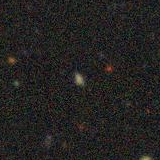

In [12]:
from PIL import Image
Image.fromarray(prepared['infer'][0]['mmu']['rgb'])